# Klassificering av ansiktsuttryck med deep learning

Detta projekt går ut på att bygga en modell med neurala nätverk som kan klassificera ansiktsutryck. 

In [36]:
# Grundläggande bibliotek
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Train/validation-split och utvärdering
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

tf.keras.utils.set_random_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 1. Förstå datan

Datasetet som används är FER-2013 och är redan uppdelat i ett träningsset och ett testset. Träningssetet används för att lära modellen klassificera ansiktsutryck medan testsetet endats används på slutat för att utvärdera modellen.

In [40]:
# Titta på datan

import os

# Räknar antal bilder totalt och per klass i tränings- och testdata

print("Antal klasser i train:", len(os.listdir("data/train")))
total_train_images = 0
for class_name in sorted(os.listdir("data/train")):
    count = len(os.listdir(f"data/train/{class_name}"))
    total_train_images += count
    print(f"{class_name}: {count} bilder")
print(f"\nTotalt antal bilder i train: {total_train_images}")

print("---------------------------------------------")

print(f"Antal klasser i test:", len(os.listdir("data/test")))
total_test_images = 0
for class_name in sorted(os.listdir("data/test")):
    count = len(os.listdir(f"data/test/{class_name}"))
    total_test_images += count
    print(f"{class_name}: {count} bilder")
print(f"\nTotalt antal bilder i test: {total_test_images}")

Antal klasser i train: 7
angry: 3995 bilder
disgust: 436 bilder
fear: 4097 bilder
happy: 7215 bilder
neutral: 4965 bilder
sad: 4830 bilder
surprise: 3171 bilder

Totalt antal bilder i train: 28709
---------------------------------------------
Antal klasser i test: 7
angry: 958 bilder
disgust: 111 bilder
fear: 1024 bilder
happy: 1774 bilder
neutral: 1233 bilder
sad: 1247 bilder
surprise: 831 bilder

Totalt antal bilder i test: 7178


### Kommentar:  
Träningsdatan består av 28709 bilder och tesdatan av 7178 bilder vilket är 20% av det totala antalet bilder 35887.  
Klassen disgust sticker ut med färre bilder 436, runt 10 procent av övriga. Störst är klassen happy med 7215 bilder som är dubbelt så stor som den nästa minsta klassen surprise med 3171 bilder.

## 2. Förbered datan

In [ ]:
# Packar upp zip-filen

import zipfile

with zipfile.ZipFile("data/FER-2013.zip", "r") as zip_ref:
    zip_ref.extractall("data/")

### Läser in data  

Datan läses in med ImageDataGenerator och normaliseras genom att pixelvärdena skalas från 0-255 till 0-1. Med flow_from_directory skalas bilderna till 48x48 pixlar och en kanal för gråskala. Labels sätts till heltal (sparse). För att underlätta vidare arbete så konverteras datan till numpy arrays.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "data/train"
test_dir = "data/test"

# Normaliserar pixelvärden från 0-255 till 0-1
datagen = ImageDataGenerator(rescale=1./255)

# Läser in bilder från mappstruktur, 48x48 gråskala, labels som heltal
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode="grayscale",
    class_mode="sparse",
    batch_size=32,
    shuffle=False
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),
    color_mode="grayscale",
    class_mode="sparse",
    batch_size=32,
    shuffle=False
)

# Konvertera till numpy-arrays
X_train_full = np.concatenate([train_generator[i][0] for i in range(len(train_generator))], axis=0)
y_train_full = np.concatenate([train_generator[i][1] for i in range(len(train_generator))], axis=0).astype(int)

X_test = np.concatenate([test_generator[i][0] for i in range(len(test_generator))], axis=0)
y_test = np.concatenate([test_generator[i][1] for i in range(len(test_generator))], axis=0).astype(int)

# Sätter klassnamn baserat på mappstruktur
class_names = list(train_generator.class_indices.keys())

print("X_train_full:", X_train_full.shape)
print("y_train_full:", y_train_full.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print(f"\nLabels på klasserna:")
for i, name in enumerate(class_names):
    print(i, name)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
X_train_full: (28709, 48, 48, 1)
y_train_full: (28709,)
X_test: (7178, 48, 48, 1)
y_test: (7178,)

Labels på klasserna:
0 angry
1 disgust
2 fear
3 happy
4 neutral
5 sad
6 surprise


### Exempelbilder

För att förstå datan bättre skrivs ett slupmässigt antal bilder med klassnamn ut.

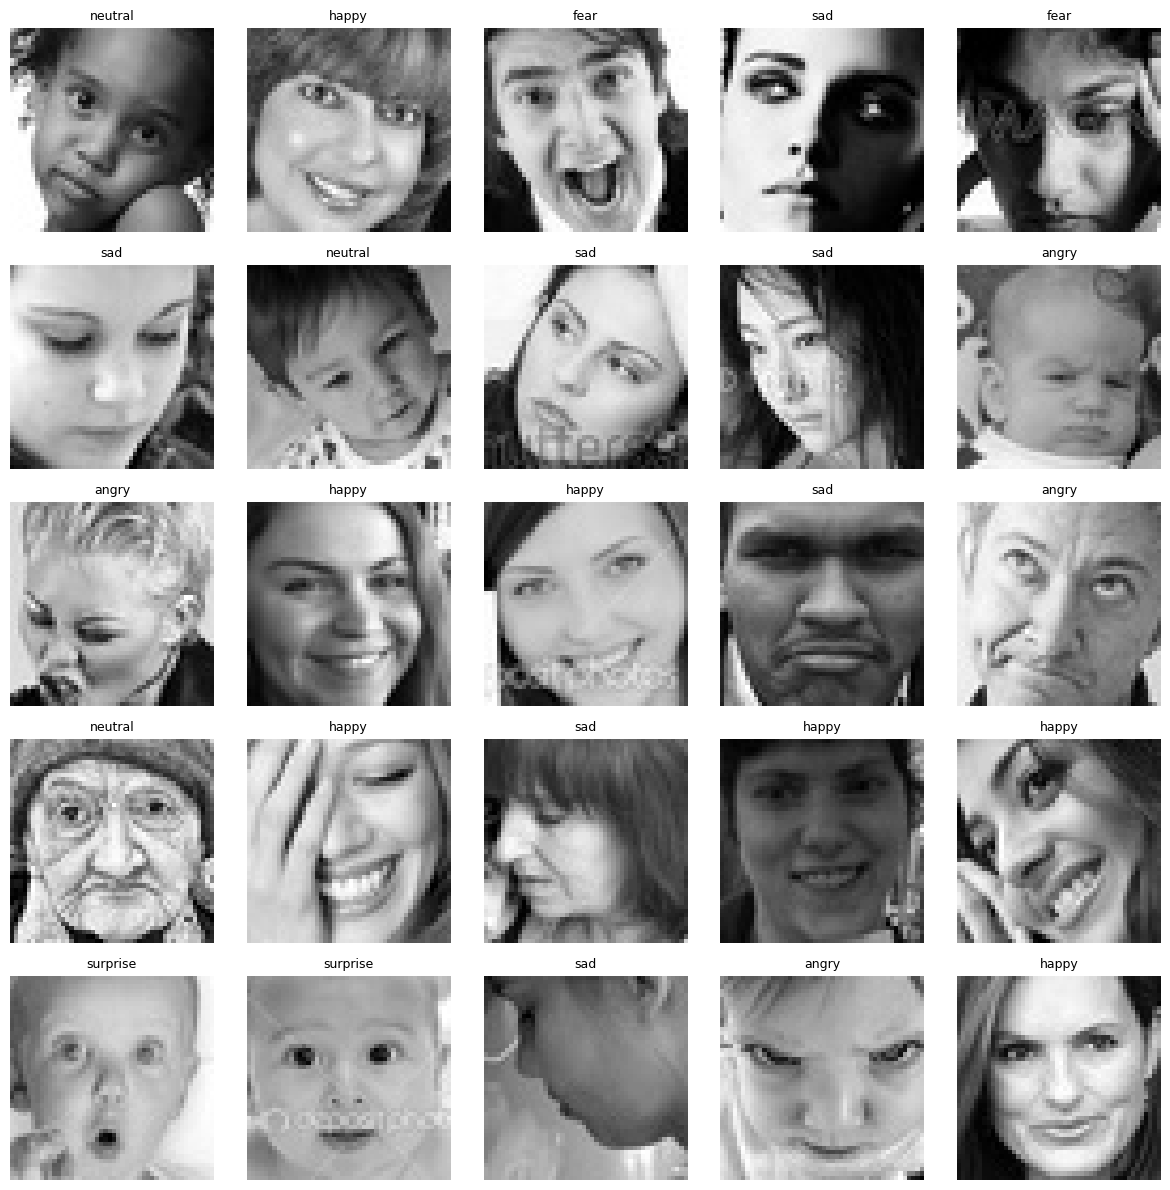

In [ ]:
# Skriver ut 25 slumpmässiga bilder från träningsdata med deras klassnamn

n_images = 25
rng = np.random.default_rng(seed=42)
indices = rng.choice(len(X_train_full), size=n_images, replace=False)
plt.figure(figsize=(12, 12))

for i in range(n_images):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train_full[indices[i]].squeeze(), cmap="gray")
    plt.title(class_names[y_train_full[indices[i]]], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Kommentar

Av de 25 slumpmässigt utvalda bilderna syns ingen disgust, vilket speglar klassens underrepresentation i datasetet.  

(Vissa av bilderna skulle jag ha tolkat som andra ansiktsuttryck vilket indikerar att denna typ av klassificering är antingen subjektiv eller att en del bilder är felklassificerade, eller båda.)

### Ta bort klassen disgust

Då klassen "disgust" innehåll betydligt färre bilder än övriga klasser så kommer klassen tas bort just nu för att få en mer robust modell. Om mer data 
samlas in i framtiden kan modellen tränas om med klassen inkluderad. 

In [ ]:
# Ta bort disgust (klass 1) i träningsdata
mask = y_train_full != 1
X_filtered = X_train_full[mask]
y_filtered = y_train_full[mask]

# Ta bort disgust från testdata
mask_test = y_test != 1
X_test_filtered = X_test[mask_test]
y_test_filtered = y_test[mask_test]

# Mappa om labels till 0-5
unique_labels = np.unique(y_filtered)
label_map = {old: new for new, old in enumerate(unique_labels)}
y_filtered = np.array([label_map[y] for y in y_filtered])
y_test_filtered = np.array([label_map[y] for y in y_test_filtered])

# Uppdatera klassnamn utan disgust
class_names_filtered = [name for name in class_names if name != "disgust"]

### Skapa subset

Träningssetet innehåller 28709 bilder vilket kan ta lång tid att träna på. Experimenten kommer därför utföras på ett balanserat subset där alla klasser får lika stor storlek, vilket ger modellen lika goda förutsättningar att lära sig känna igen varje klass. När en optimal modell hittats kan träning ske på hela träningsdatan.

In [ ]:
# Skapar ett balanserat subset med 500 bilder per klass
samples_per_class=500
rng = np.random.default_rng(42)
selected_indices = []

for class_id in np.unique(y_filtered):
    class_indices = np.where(y_filtered == class_id)[0]   
    chosen_indices = rng.choice(class_indices, size=samples_per_class, replace=False)
    selected_indices.extend(chosen_indices)

selected_indices = np.array(selected_indices)
rng.shuffle(selected_indices)

X_subset = X_filtered[selected_indices]
y_subset = y_filtered[selected_indices]

# Utskrift för kontroll av shapes och klassfördelning i det nya subsetet
print("X_subset:", X_subset.shape)
print("y_subset:", y_subset.shape)
print("\nLabels på klasserna efter borttagning av disgust och subset:")
unique, counts = np.unique(y_subset, return_counts=True)
for label, count in zip(unique, counts):
    print(f"{label} {class_names_filtered[label]}: {count} bilder")

X_subset: (3000, 48, 48, 1)
y_subset: (3000,)

Labels på klasserna efter borttagning av disgust och subset:
0 angry: 500 bilder
1 fear: 500 bilder
2 happy: 500 bilder
3 neutral: 500 bilder
4 sad: 500 bilder
5 surprise: 500 bilder


### Skapa valideringsset

Ett valideringsdataset skapas av 20% av träningsdatan för att kunna utvärdera hur modellen presterar på data den inte tränats på. Under träningen 
används valideringsdatan för att upptäcka om modellen lär sig träningsdatan för bra och överanpassar.

Eftersom subsettet redan är balanserat är stratifiering inte nödvändigt men används ändå som en säkerhetsåtgärd.

In [ ]:
# Skapa validationsset från det nya subsetet (20% av datan)
X_train, X_val, y_train, y_val = train_test_split(
    X_subset,
    y_subset,
    test_size=0.20,
    random_state=42,
    stratify=y_subset
)

# Utskrift för kontroll av shapes i train/val-split
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (2400, 48, 48, 1)
X_val: (600, 48, 48, 1)
y_train: (2400,)
y_val: (600,)


## 3 och 4. Bygg en modell, träna modellen

### Funktion för att bygga och compilera modeller

Modellen är ett CNN (Convolutional Neural Network) med två eller tre Conv2D-lager som extraherar visuella mönster från bilderna, följt av MaxPooling-lager som reducerar bildernas storlek. Därefter plattas datan ut med ett Flatten-lager och skickas vidare till ett fully connected lager (Dense) som lär sig kombinera mönstren för klassificering. Sista lagret har 6 noder med softmax-aktivering, ett per känslouttryck, som ger sannolikheten för varje klass. Dropout och L2-regularisering kan läggas till för att motverka överanpassning.

Grundinställningar: 32 och 64 filter i de två första Conv2D-lagren, kernelstorlek 3×3, 128 noder i det fully connected lagret och learning rate 0.001 med Adam som optimerare. Dessa värden justeras i de följande experimenten.

In [ ]:
def build_model(
        num_filters_1=32,
        num_filters_2=64,
        num_filters_3=None,
        kernel_size=(3, 3),
        dense_units=128,
        learning_rate=0.001,
        dropout_rate=0.0,
        l2_strength=0.0
):
    """
    Bygger och kompilerar en CNN med två eller tre Conv2D-lager följt av ett fully connected lager (dense).
    Stöder dropout och L2-regularisering som hyperparametrar.

    Returnerar: kompilerad Keras-modell
    """
    tf.keras.utils.set_random_seed(42)
    
    kernels_regularizer = (
        regularizers.l2(l2_strength)
        if l2_strength > 0
        else None
    )

    model = keras.Sequential([
        layers.Input(shape=(48, 48, 1)),

        layers.Conv2D(num_filters_1, kernel_size=kernel_size, activation="relu",
                      padding="same", kernel_regularizer=kernels_regularizer),

        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(num_filters_2, kernel_size=kernel_size, activation="relu",
                      padding="same", kernel_regularizer=kernels_regularizer),
                      
        layers.MaxPooling2D(pool_size=(2, 2)),
    ])

    # Valfritt tredje Conv2D-lager
    if num_filters_3:
        model.add(layers.Conv2D(num_filters_3, kernel_size=kernel_size, activation="relu",
                                padding="same", kernel_regularizer=kernels_regularizer))
        
        model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    model.add(layers.Flatten())

    model.add(layers.Dense(dense_units, activation="relu",
                            kernel_regularizer=kernels_regularizer))
        
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(6, activation="softmax"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

### Funktion för att skapa träningskurvor

Träningskurvorna visar hur modellens loss och accuracy utvecklas över epoker för både tränings- och valideringsdata. Kurvorna används för att bedöma om 
modellen lär sig och om det finns tecken på överanpassning.

In [ ]:
def plot_history(history, title="Träningskurvor"):

    """
    Plottar tränings- och valideringsförlust samt accuracy över epoker.
    """

    # Konverterar Keras History-objekt till DataFrame för enklare plottning    
    history_df = pd.DataFrame(history.history)

    epochs = range(1, len(history_df) + 1)

    plt.figure(figsize=(12, 4))

    # Plottar loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_df["loss"], label="Traning loss")
    plt.plot(epochs, history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epok")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    # Plottar accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_df["accuracy"], label="Traning accuracy")
    plt.plot(epochs, history_df["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epok")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

### Funktion för att köra experiment och träna modeller

Experimenten körs med funktionen run_experiment som bygger och tränar en modell med angivna hyperparametrar. Resultaten sparas i en lista för att enkelt kunna jämföras mellan experiment. Alla mått hämtas från den epok som gav bäst valideringsnoggrannhet, vilket inte alltid behöver vara den sista.

In [ ]:
def run_experiment(
        name,
        epochs=15,
        learning_rate=0.001,
        batch_size=64,
        num_filters_1=32,
        num_filters_2=64,
        num_filters_3=None,
        kernel_size=(3, 3),
        dense_units=128,
        dropout_rate=0.0,
        l2_strength=0.0,
        callbacks=None,
        verbose=0
):
    
    """
    Bygger, tränar och utvärderar en modell med angivna hyperparametrar.
    Returnerar: modell, history och dict med resultatmått.
    """

    model = build_model(
        num_filters_1=num_filters_1,
        num_filters_2=num_filters_2,
        num_filters_3=num_filters_3,
        kernel_size=kernel_size,
        dense_units=dense_units,
        learning_rate=learning_rate,
        dropout_rate=dropout_rate,
        l2_strength=l2_strength
    )

    print(f"\nExperiment: {name}")
    start_time = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose
    )

    training_time = time.time() - start_time

    # Hämtar resultat från bästa epok baserat på val_accuracy
    best_index = np.argmax(history.history["val_accuracy"])

    train_acc  = history.history["accuracy"][best_index]
    train_loss = history.history["loss"][best_index]
    val_acc  = history.history["val_accuracy"][best_index]
    val_loss = history.history["val_loss"][best_index]


    print(f"Antal epoker:   {len(history.history['loss'])}")
    print(f"Training accuracy:      {train_acc:.4f}")
    print(f"Training loss:          {train_loss:.4f}")
    print(f"Validation accuracy: {val_acc:.4f}")
    print(f"Validation loss:     {val_loss:.4f}")
    print(f"Träningstid:    {training_time:.2f} sekunder")

    plot_history(history, title=name)

    return model, history, {
        "name": name,
        "train_accuracy": train_acc,
        "train_loss": train_loss,
        "val_accuracy": val_acc,
        "val_loss": val_loss,
        "epochs_trained": len(history.history["loss"]),
        "training_time": training_time
    }

### Experiment

Experimenten utgår från en basmodell och förändringar görs iterativt utifrån resultaten.


Experiment: Basmodell
Antal epoker:   15
Training accuracy:      0.7950
Training loss:          0.5968
Validation accuracy: 0.3600
Validation loss:     2.1927
Träningstid:    19.77 sekunder


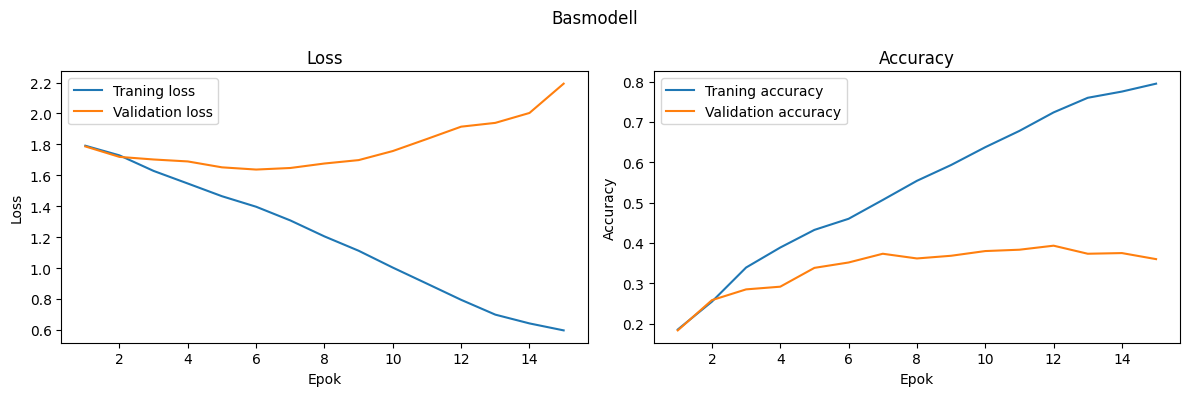

     name  train_accuracy  train_loss  val_accuracy  val_loss  epochs_trained  training_time
Basmodell           0.795    0.596786          0.36  2.192748              15      19.765681


In [12]:
# Basmodell

results = []

_, h_bas, r_bas = run_experiment("Basmodell")

results.append(r_bas)

print(pd.DataFrame(results).to_string(index=False))

### Kommentar

Basmodellen överanpassar nästan omgående och efter 15 epoker når accuracy på träningsdatan 0,80 men på valideringsdatan bara 0,36.  
Ett nästa steg är att prova olika dropout-nivåer där en del av neuronen inte används.


Experiment: Dropout 0.2
Antal epoker:   15
Training accuracy:      0.7788
Training loss:          0.6184
Validation accuracy: 0.3750
Validation loss:     2.0913
Träningstid:    21.39 sekunder


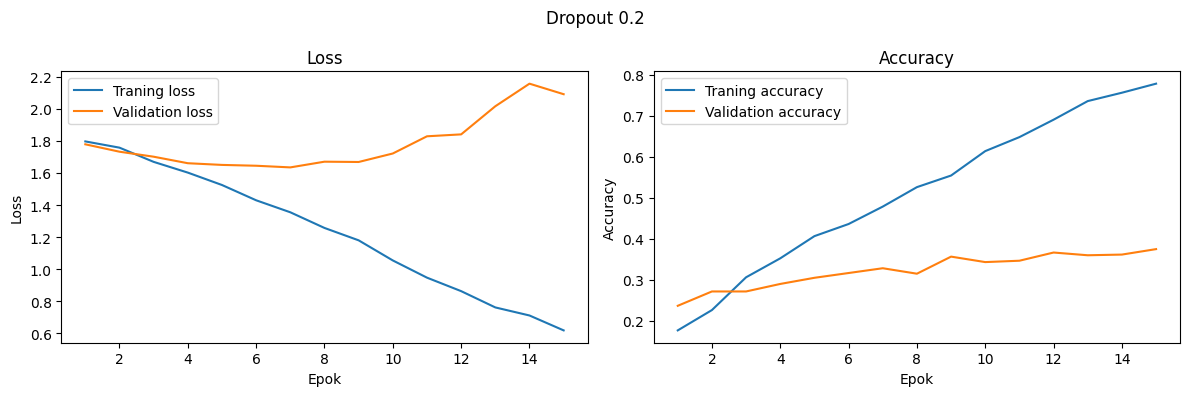


Experiment: Dropout 0.4
Antal epoker:   15
Training accuracy:      0.6500
Training loss:          0.9302
Validation accuracy: 0.3733
Validation loss:     1.7231
Träningstid:    20.98 sekunder


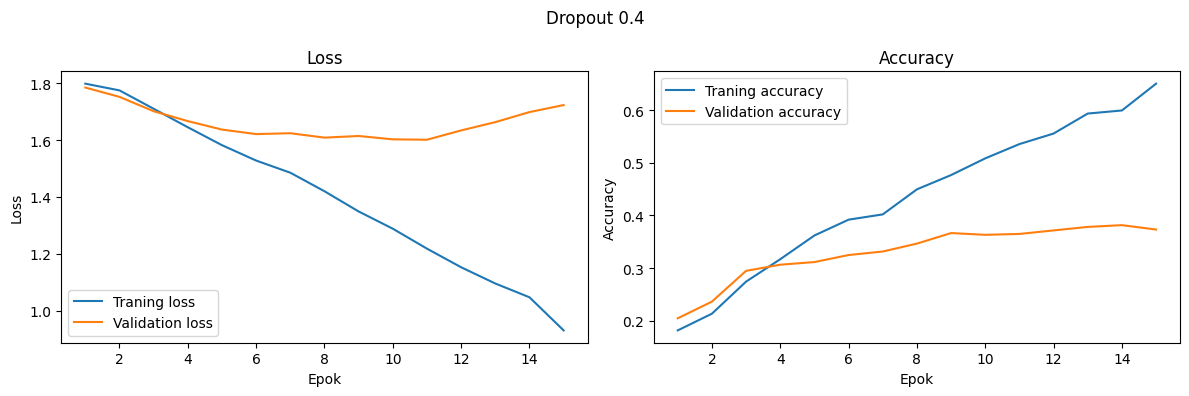


Experiment: Dropout 0.5
Antal epoker:   15
Training accuracy:      0.6250
Training loss:          0.9694
Validation accuracy: 0.3500
Validation loss:     1.6985
Träningstid:    21.45 sekunder


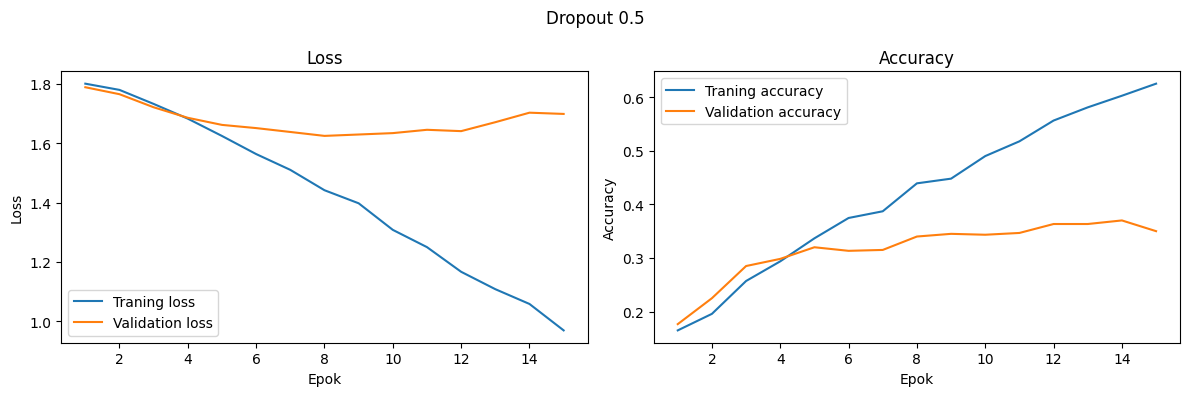

       name  train_accuracy  train_loss  val_accuracy  val_loss  epochs_trained  training_time
  Basmodell         0.79500    0.596786      0.360000  2.192748              15      19.765681
Dropout 0.2         0.77875    0.618427      0.375000  2.091327              15      21.389057
Dropout 0.4         0.65000    0.930234      0.373333  1.723146              15      20.975471
Dropout 0.5         0.62500    0.969357      0.350000  1.698543              15      21.448182


In [13]:
# Experiment med olika dropout

_, h_drop1, r_drop1 = run_experiment("Dropout 0.2", dropout_rate=0.2)
_, h_drop2, r_drop2 = run_experiment("Dropout 0.4", dropout_rate=0.4)
_, h_drop3, r_drop3 = run_experiment("Dropout 0.5", dropout_rate=0.5)

results.extend([r_drop1, r_drop2, r_drop3])
print(pd.DataFrame(results).to_string(index=False))

### Kommentar

Med dropout 0,2 fås den hittils bästa accuracy på valideringsdatan. Tillsammans med att accuracy på träningsdatan sjunker så ger detta det minsta gapet dem emellan. Även om dropout 0,2 inte har minst loss på valideringsdatan så väljs detta att gå vidare med då accuracy prioiteras.  

För att ytterligare minska överanpassning testas olika l2-styrkor som straffar modellen om den har för stora vikter.


Experiment: Dropout 0.2 + L2 0.01
Antal epoker:   15
Training accuracy:      0.2788
Training loss:          1.7338
Validation accuracy: 0.2750
Validation loss:     1.7367
Träningstid:    24.28 sekunder


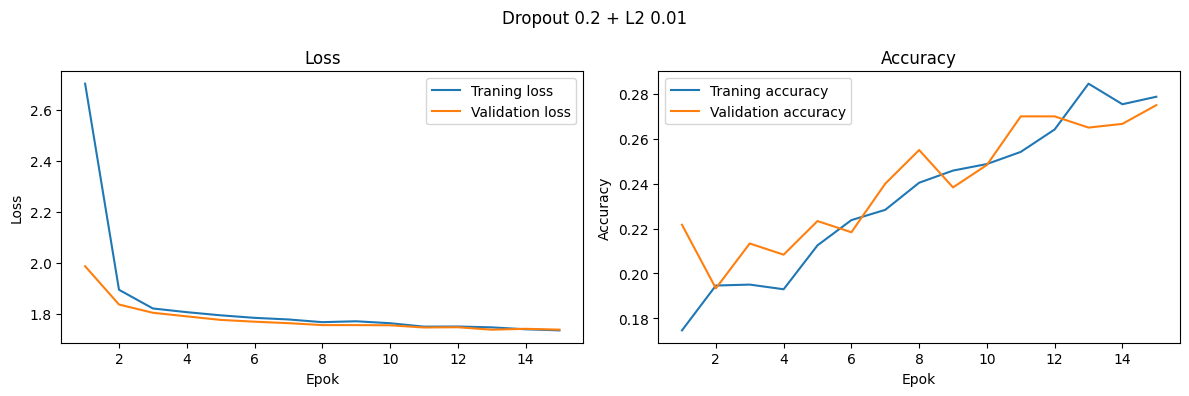


Experiment: Dropout 0.2 + L2 0.001
Antal epoker:   15
Training accuracy:      0.6012
Training loss:          1.1975
Validation accuracy: 0.3550
Validation loss:     1.8600
Träningstid:    24.16 sekunder


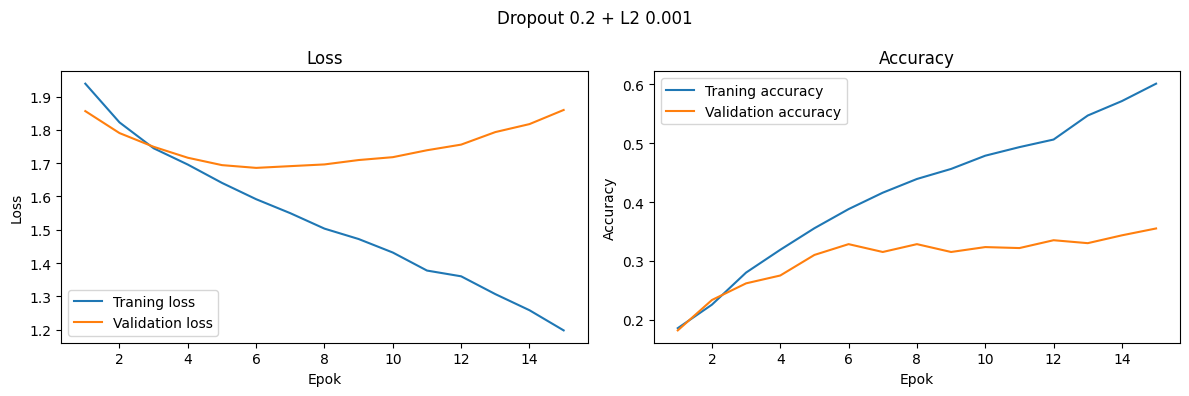


Experiment: Dropout 0.2 + L2 0.0001
Antal epoker:   15
Training accuracy:      0.7342
Training loss:          0.7915
Validation accuracy: 0.3733
Validation loss:     1.8674
Träningstid:    22.51 sekunder


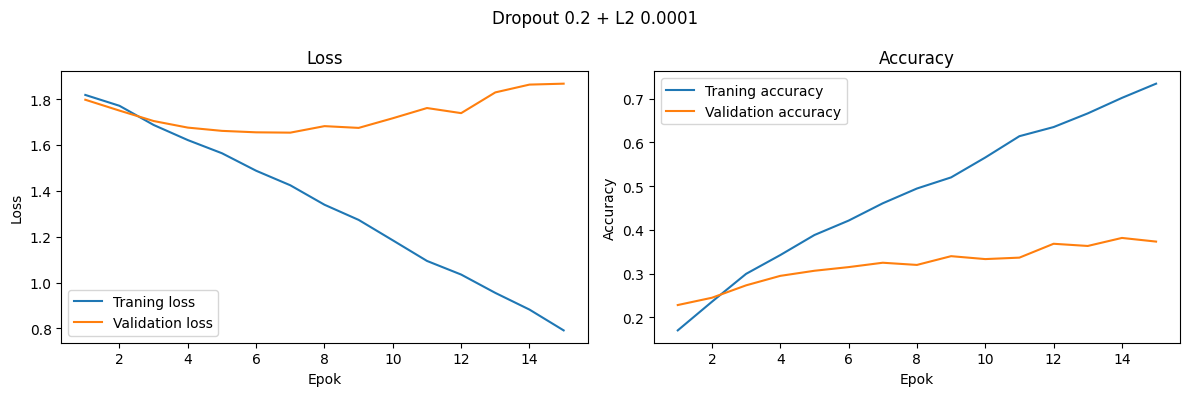

                   name  train_accuracy  train_loss  val_accuracy  val_loss  epochs_trained  training_time
              Basmodell        0.795000    0.596786      0.360000  2.192748              15      19.765681
            Dropout 0.2        0.778750    0.618427      0.375000  2.091327              15      21.389057
            Dropout 0.4        0.650000    0.930234      0.373333  1.723146              15      20.975471
            Dropout 0.5        0.625000    0.969357      0.350000  1.698543              15      21.448182
  Dropout 0.2 + L2 0.01        0.278750    1.733827      0.275000  1.736746              15      24.275151
 Dropout 0.2 + L2 0.001        0.601250    1.197545      0.355000  1.859994              15      24.156167
Dropout 0.2 + L2 0.0001        0.734167    0.791458      0.373333  1.867401              15      22.508813


In [14]:
# Experiment med olika L2-styrkor

_, h_l2_1, r_l2_1 = run_experiment("Dropout 0.2 + L2 0.01", dropout_rate=0.2, l2_strength=0.01)
_, h_l2_2, r_l2_2 = run_experiment("Dropout 0.2 + L2 0.001", dropout_rate=0.2, l2_strength=0.001)
_, h_l2_3, r_l2_3 = run_experiment("Dropout 0.2 + L2 0.0001", dropout_rate=0.2, l2_strength=0.0001)

results.extend([r_l2_1, r_l2_2, r_l2_3])
print(pd.DataFrame(results).to_string(index=False))

### Kommentar

L2-regularisering gav ingen förbättring utan modellen men dropout 0,2 är fortfarande har högst accuracy på valideringsdatan. Att testa early stopping bedöms inte meningsfullt då överanpassning fortfarande inom 6-8 epoker. Nästa experiment görs med olika learning rates.


Experiment: Dropout 0.2 + LR 0.0001
Antal epoker:   15
Training accuracy:      0.4392
Training loss:          1.4561
Validation accuracy: 0.3567
Validation loss:     1.6153
Träningstid:    20.28 sekunder


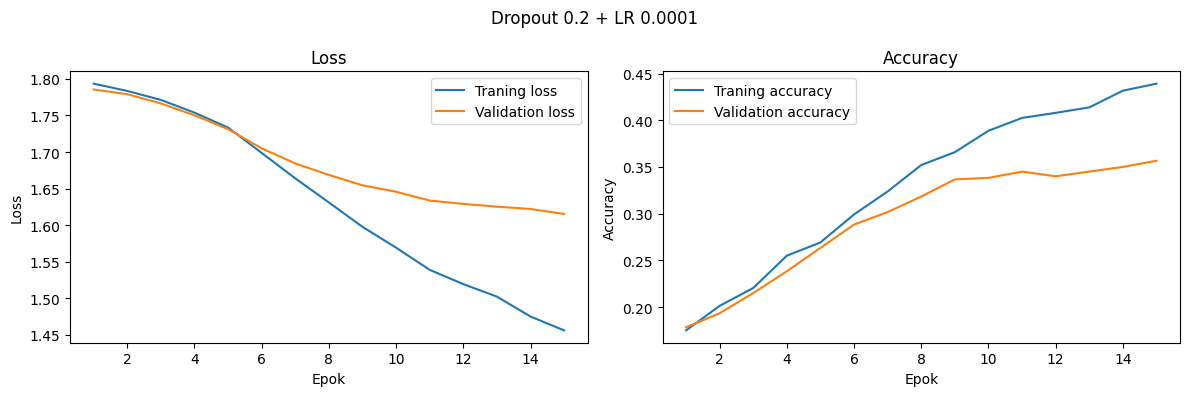


Experiment: Dropout 0.2 + LR 0.0005
Antal epoker:   15
Training accuracy:      0.6888
Training loss:          0.9039
Validation accuracy: 0.3733
Validation loss:     1.6675
Träningstid:    21.86 sekunder


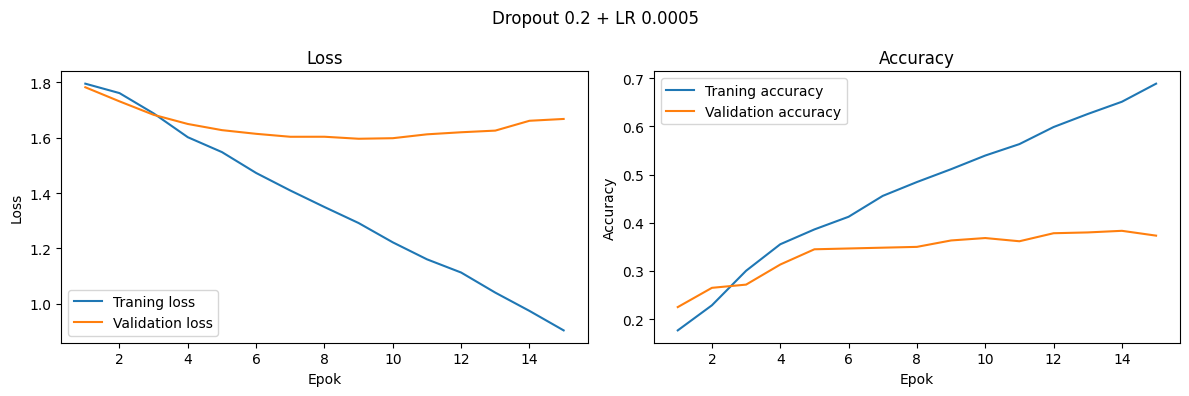


Experiment: Dropout 0.2 + LR 0.01
Antal epoker:   15
Training accuracy:      0.3729
Training loss:          1.5122
Validation accuracy: 0.2450
Validation loss:     2.0776
Träningstid:    22.67 sekunder


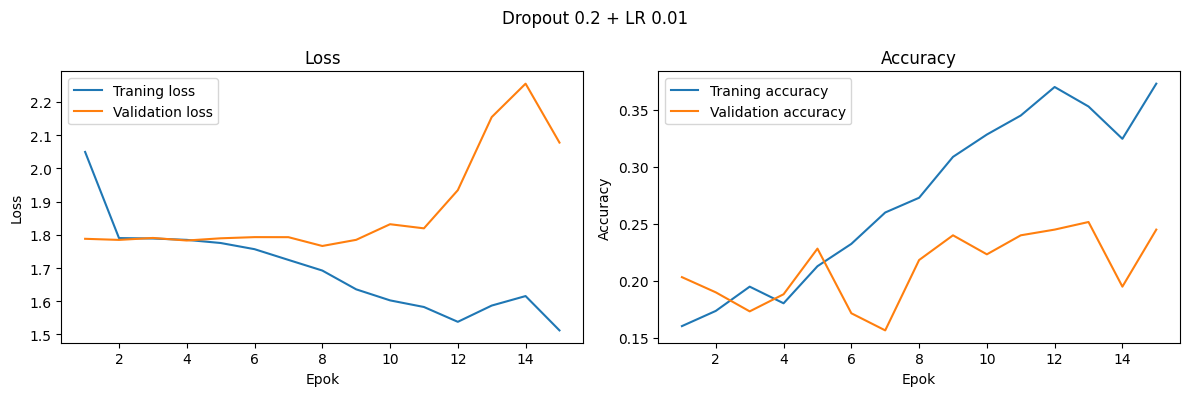

                   name  train_accuracy  train_loss  val_accuracy  val_loss  epochs_trained  training_time
              Basmodell        0.795000    0.596786      0.360000  2.192748              15      19.765681
            Dropout 0.2        0.778750    0.618427      0.375000  2.091327              15      21.389057
            Dropout 0.4        0.650000    0.930234      0.373333  1.723146              15      20.975471
            Dropout 0.5        0.625000    0.969357      0.350000  1.698543              15      21.448182
  Dropout 0.2 + L2 0.01        0.278750    1.733827      0.275000  1.736746              15      24.275151
 Dropout 0.2 + L2 0.001        0.601250    1.197545      0.355000  1.859994              15      24.156167
Dropout 0.2 + L2 0.0001        0.734167    0.791458      0.373333  1.867401              15      22.508813
Dropout 0.2 + LR 0.0001        0.439167    1.456122      0.356667  1.615281              15      20.283102
Dropout 0.2 + LR 0.0005        0.6887

In [15]:
# Experiment med olika learning rates

_, h_lr1, r_lr1 = run_experiment("Dropout 0.2 + LR 0.0001", dropout_rate=0.2, learning_rate=0.0001)
_, h_lr2, r_lr2 = run_experiment("Dropout 0.2 + LR 0.0005", dropout_rate=0.2, learning_rate=0.0005)
_, h_lr3, r_lr3 = run_experiment("Dropout 0.2 + LR 0.01", dropout_rate=0.2, learning_rate=0.01)

results.extend([r_lr1, r_lr2, r_lr3])
print(pd.DataFrame(results).to_string(index=False))

### Kommentar

De testade learning rates gav ingen förbättring utan learning rate 0,001 som användes som grund är tillsammans med droput 0,2 bäst hittils.  

I nästa experiment testas en större modell för att se om den kan bli bättre på att lära sig de mer komplexa mönster som ansiktsuttryck är.


Experiment: Större modell + dropout 0.2
Antal epoker:   15
Training accuracy:      0.8321
Training loss:          0.4983
Validation accuracy: 0.3483
Validation loss:     2.3623
Träningstid:    59.75 sekunder


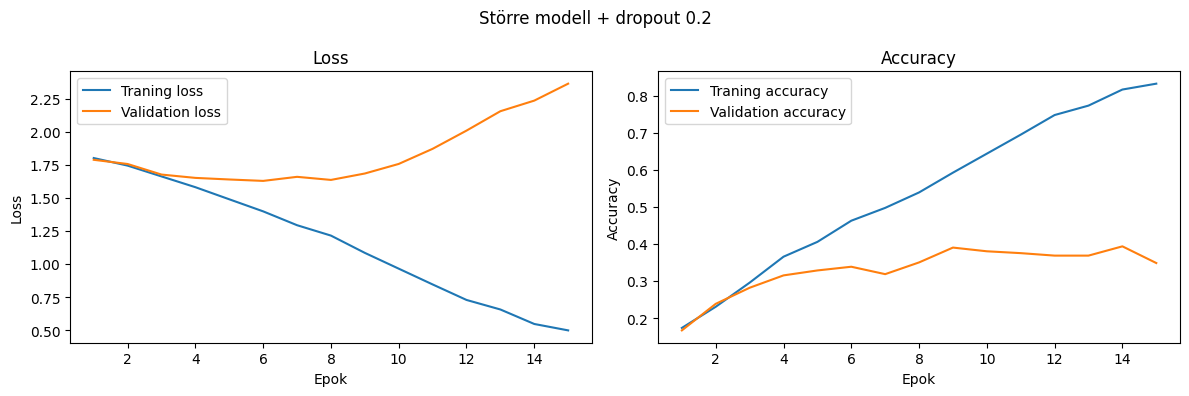

                       name  train_accuracy  train_loss  val_accuracy  val_loss  epochs_trained  training_time
                  Basmodell        0.795000    0.596786      0.360000  2.192748              15      19.765681
                Dropout 0.2        0.778750    0.618427      0.375000  2.091327              15      21.389057
                Dropout 0.4        0.650000    0.930234      0.373333  1.723146              15      20.975471
                Dropout 0.5        0.625000    0.969357      0.350000  1.698543              15      21.448182
      Dropout 0.2 + L2 0.01        0.278750    1.733827      0.275000  1.736746              15      24.275151
     Dropout 0.2 + L2 0.001        0.601250    1.197545      0.355000  1.859994              15      24.156167
    Dropout 0.2 + L2 0.0001        0.734167    0.791458      0.373333  1.867401              15      22.508813
    Dropout 0.2 + LR 0.0001        0.439167    1.456122      0.356667  1.615281              15      20.283102
 

In [16]:
# Experiment med större modell

_, h_big, r_big = run_experiment(
    "Större modell + dropout 0.2",
    num_filters_1=64,
    num_filters_2=128,
    dense_units=256,
    dropout_rate=0.2
)

results.append(r_big)
print(pd.DataFrame(results).to_string(index=False))

### Kommentar

En större modell överanpassar ännu mer med 0,85 i accuracy på träningsdatan och 0,36 på valideringsdatan.

### Träna modellen på hela träningsdatan

Modellen som väljs är basmodellen med dropout 0,2.  

Med mer data blir det också intressant att testa en modell med ett tredje Conv2D-lager.

In [ ]:
# Skapa tränings- och valideringsuppsättningar med alla bilder (utan disgust)
X_train_full, X_val_full, y_train_full, y_val_full = train_test_split(
    X_filtered,
    y_filtered,
    test_size=0.20,
    random_state=42,
    stratify=y_filtered
)

# Utskrift för kontroll av shapes i train/val-split
print("X_train:", X_train_full.shape)
print("X_val:", X_val_full.shape)
print("y_train:", y_train_full.shape)
print("y_val:", y_val_full.shape)

X_train: (22618, 48, 48, 1)
X_val: (5655, 48, 48, 1)
y_train: (22618,)
y_val: (5655,)



Experiment: Dropout 0,2 på full data
Antal epoker:   15
Training accuracy:      0.8085
Training loss:          0.5133
Validation accuracy: 0.5052
Validation loss:     1.6926
Träningstid:    179.97 sekunder


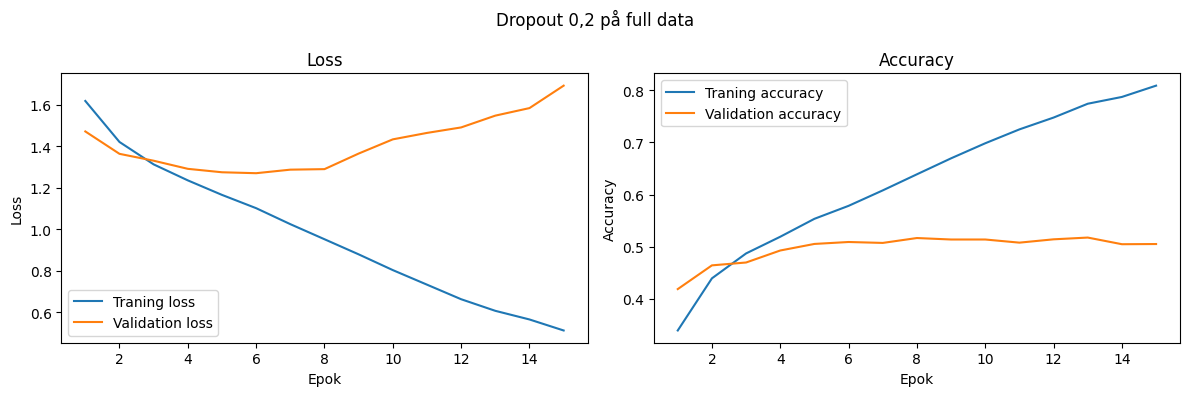

                       name  train_accuracy  train_loss  val_accuracy  val_loss  epochs_trained  training_time
                  Basmodell        0.795000    0.596786      0.360000  2.192748              15      19.765681
                Dropout 0.2        0.778750    0.618427      0.375000  2.091327              15      21.389057
                Dropout 0.4        0.650000    0.930234      0.373333  1.723146              15      20.975471
                Dropout 0.5        0.625000    0.969357      0.350000  1.698543              15      21.448182
      Dropout 0.2 + L2 0.01        0.278750    1.733827      0.275000  1.736746              15      24.275151
     Dropout 0.2 + L2 0.001        0.601250    1.197545      0.355000  1.859994              15      24.156167
    Dropout 0.2 + L2 0.0001        0.734167    0.791458      0.373333  1.867401              15      22.508813
    Dropout 0.2 + LR 0.0001        0.439167    1.456122      0.356667  1.615281              15      20.283102
 

In [ ]:
# Bygger och tränar en modell med alla bilder (utan disgust) och med dropout 0.2
X_train = X_train_full
X_val = X_val_full
y_train = y_train_full
y_val = y_val_full

model_dropout_full, h_dropout_full, r_dropout_full = run_experiment(
    "Dropout 0,2 på full data",
    dropout_rate=0.2
)

results.append(r_dropout_full)
print(pd.DataFrame(results).to_string(index=False))


Experiment: Final model - Dropout 0,2 + 3 Conv2D-lager
Antal epoker:   15
Training accuracy:      0.8037
Training loss:          0.5134
Validation accuracy: 0.5330
Validation loss:     1.7078
Träningstid:    226.95 sekunder


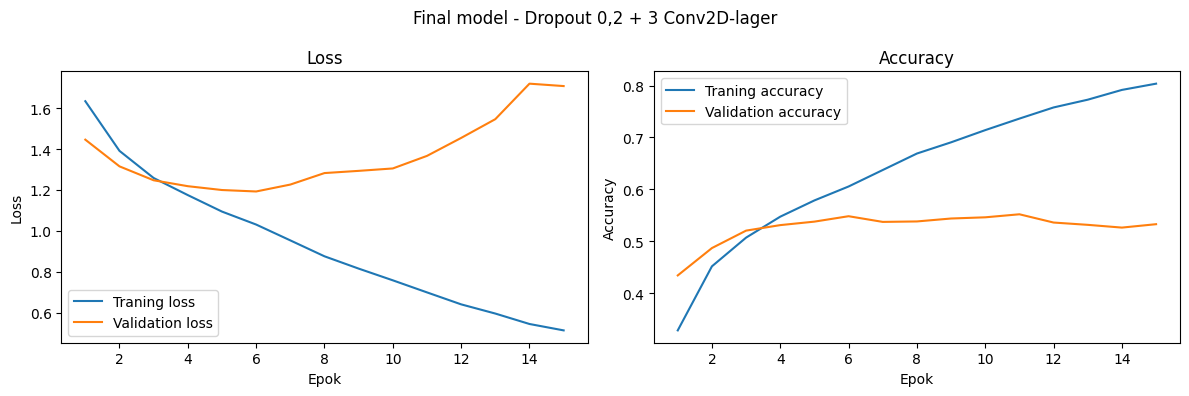

                                      name  train_accuracy  train_loss  val_accuracy  val_loss  epochs_trained  training_time
                                 Basmodell        0.795000    0.596786      0.360000  2.192748              15      19.765681
                               Dropout 0.2        0.778750    0.618427      0.375000  2.091327              15      21.389057
                               Dropout 0.4        0.650000    0.930234      0.373333  1.723146              15      20.975471
                               Dropout 0.5        0.625000    0.969357      0.350000  1.698543              15      21.448182
                     Dropout 0.2 + L2 0.01        0.278750    1.733827      0.275000  1.736746              15      24.275151
                    Dropout 0.2 + L2 0.001        0.601250    1.197545      0.355000  1.859994              15      24.156167
                   Dropout 0.2 + L2 0.0001        0.734167    0.791458      0.373333  1.867401              15      22

In [ ]:
# Bygger och tränar en modell med alla bilder (utan disgust) och med dropout 0.2 och ett tredje Conv2D-lager
model_dropout_3layers_full, h_dropout_3layers_full, r_dropout_3layers_full = run_experiment(
    "Dropout 0,2 + 3 Conv2D-lager",
    dropout_rate=0.2,
    num_filters_3=128
)

results.append(r_dropout_3layers_full)
print(pd.DataFrame(results).to_string(index=False))

In [20]:
final_model = model_dropout_3layers_full
final_model.save("final_model.keras")

### Kommentar

Mer data gav en förbättring med bäst accuracy på valideringsdatan och ett mindre överanpassningsgap (80% train vs 53% val).

Med subsetet gav en större modell ingen förbättring, men med full träningsdata gav en djupare modell (tre Conv2D-lager) bättre resultat. Detta stödjer att CNN-modeller behöver tillräckligt med data för att dra nytta av ökad komplexitet.

### Felanalys

För att förstå var modellen misslyckas analyseras prediktionerna på valideringsdatan. Konfusionsmatrisen visar hur många bilder som klassificerats rätt respektive fel per klass, och per-klass accuracy identifierar vilka känslor som är svårast att känna igen. Slutligen visas exempel på felklassificerade bilder tillsammans med modellens säkerhet.

In [21]:
def predict_classes(model, X):

    """
    Returnerar predikterade klasser och sannolikheter för en modell.
    """
    
    y_proba = model.predict(X, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)

    return y_pred, y_proba

In [ ]:
# Predikterar klasser och sannolikheter på valideringsdatan
final_model_val_pred, final_model_val_proba = predict_classes(final_model, X_val)

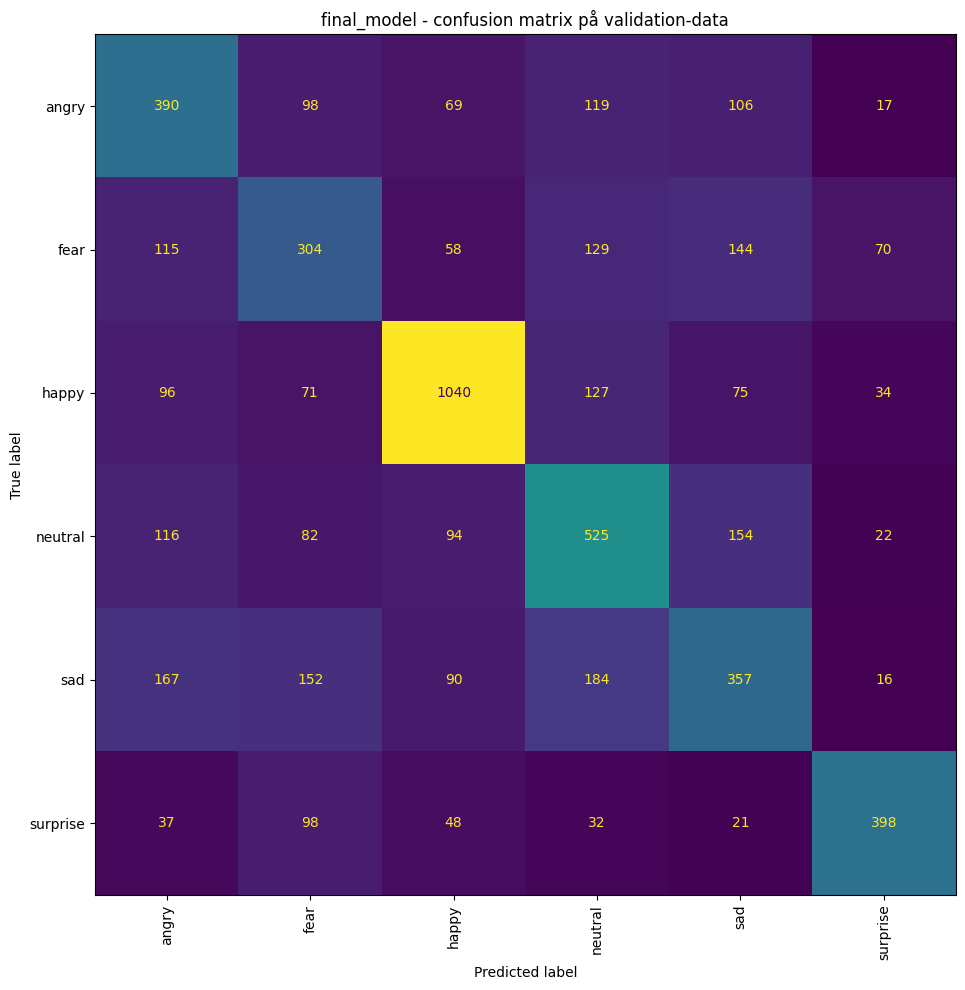

In [ ]:
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion matrix"):

    """
    Plottar en konfusionsmatris och returnerar den som numpy-array.
    """

    labels = np.arange(len(class_names))

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    fig, ax = plt.subplots(figsize=(12, 10))

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    display.plot(
        ax=ax,
        xticks_rotation=90,
        values_format="d",
        colorbar=False
    )

    plt.title(title)
    plt.tight_layout()
    plt.show()

    return cm

# Konfusionsmatris på valideringsdatan
final_model_cm = plot_confusion_matrix(
    y_val,
    final_model_val_pred,
    class_names_filtered,
    title="final_model - confusion matrix på validation-data")

In [ ]:
def calculate_per_class_accuracy(cm, class_names):

    """
    Beräknar accuracy per klass från en konfusionsmatris.
    Returnerar en DataFrame sorterad efter accuracy (lägst först).
    """

    support = cm.sum(axis=1)
    correct = np.diag(cm)

    accuracy = correct / support

    result = pd.DataFrame({
        "class_id": np.arange(len(class_names)),
        "class_name": class_names,
        "support": support,
        "correct": correct,
        "accuracy": accuracy
    })

    return result.sort_values("accuracy")


final_model_per_class = calculate_per_class_accuracy(
    final_model_cm,
    class_names_filtered
)

print("Per-klass accuracy på valideringsdata")

# Per-klass accuracy sorterad från sämst till bäst
final_model_per_class.style\
    .format({"accuracy": "{:.1%}"})\
    .background_gradient(subset=["accuracy"], cmap="RdYlGn")

Per-klass accuracy på valideringsdata


,class_id,class_name,support,correct,accuracy
4,4,sad,966,357,37.0%
1,1,fear,820,304,37.1%
0,0,angry,799,390,48.8%
3,3,neutral,993,525,52.9%
5,5,surprise,634,398,62.8%
2,2,happy,1443,1040,72.1%


In [ ]:
def get_most_confused_pairs(cm, class_names, top_n=10):

    """
    Returnerar de vanligaste felklassificeringarna som en DataFrame.
    Sorterad efter antal fel, högst först.
    """

    pairs = []

    for true_class in range(cm.shape[0]):
        for predicted_class in range(cm.shape[1]):
            if true_class == predicted_class:
                continue

            count = cm[true_class, predicted_class]

            if count > 0:
                pairs.append({
                    "true_class_id": true_class,
                    "true_class": class_names[true_class],
                    "predicted_class_id": predicted_class,
                    "predicted_class": class_names[predicted_class],
                    "count": count
                })

    pairs_df = pd.DataFrame(pairs)

    if pairs_df.empty:
        return pairs_df

    return pairs_df.sort_values("count", ascending=False).head(top_n)

final_model_confusions = get_most_confused_pairs(
    final_model_cm,
    class_names_filtered
)

print("Mest felklassificerade par på valideringsdata")

# De 10 vanligaste felklassificeringarna
final_model_confusions.style\
    .background_gradient(subset=["count"], cmap="RdYlGn_r")


Mest felklassificerade par på valideringsdata


,true_class_id,true_class,predicted_class_id,predicted_class,count
23,4,sad,3,neutral,184
20,4,sad,0,angry,167
18,3,neutral,4,sad,154
21,4,sad,1,fear,152
8,1,fear,4,sad,144
7,1,fear,3,neutral,129
12,2,happy,3,neutral,127
2,0,angry,3,neutral,119
15,3,neutral,0,angry,116
5,1,fear,0,angry,115


Antal felklassificerade exempel: 2641


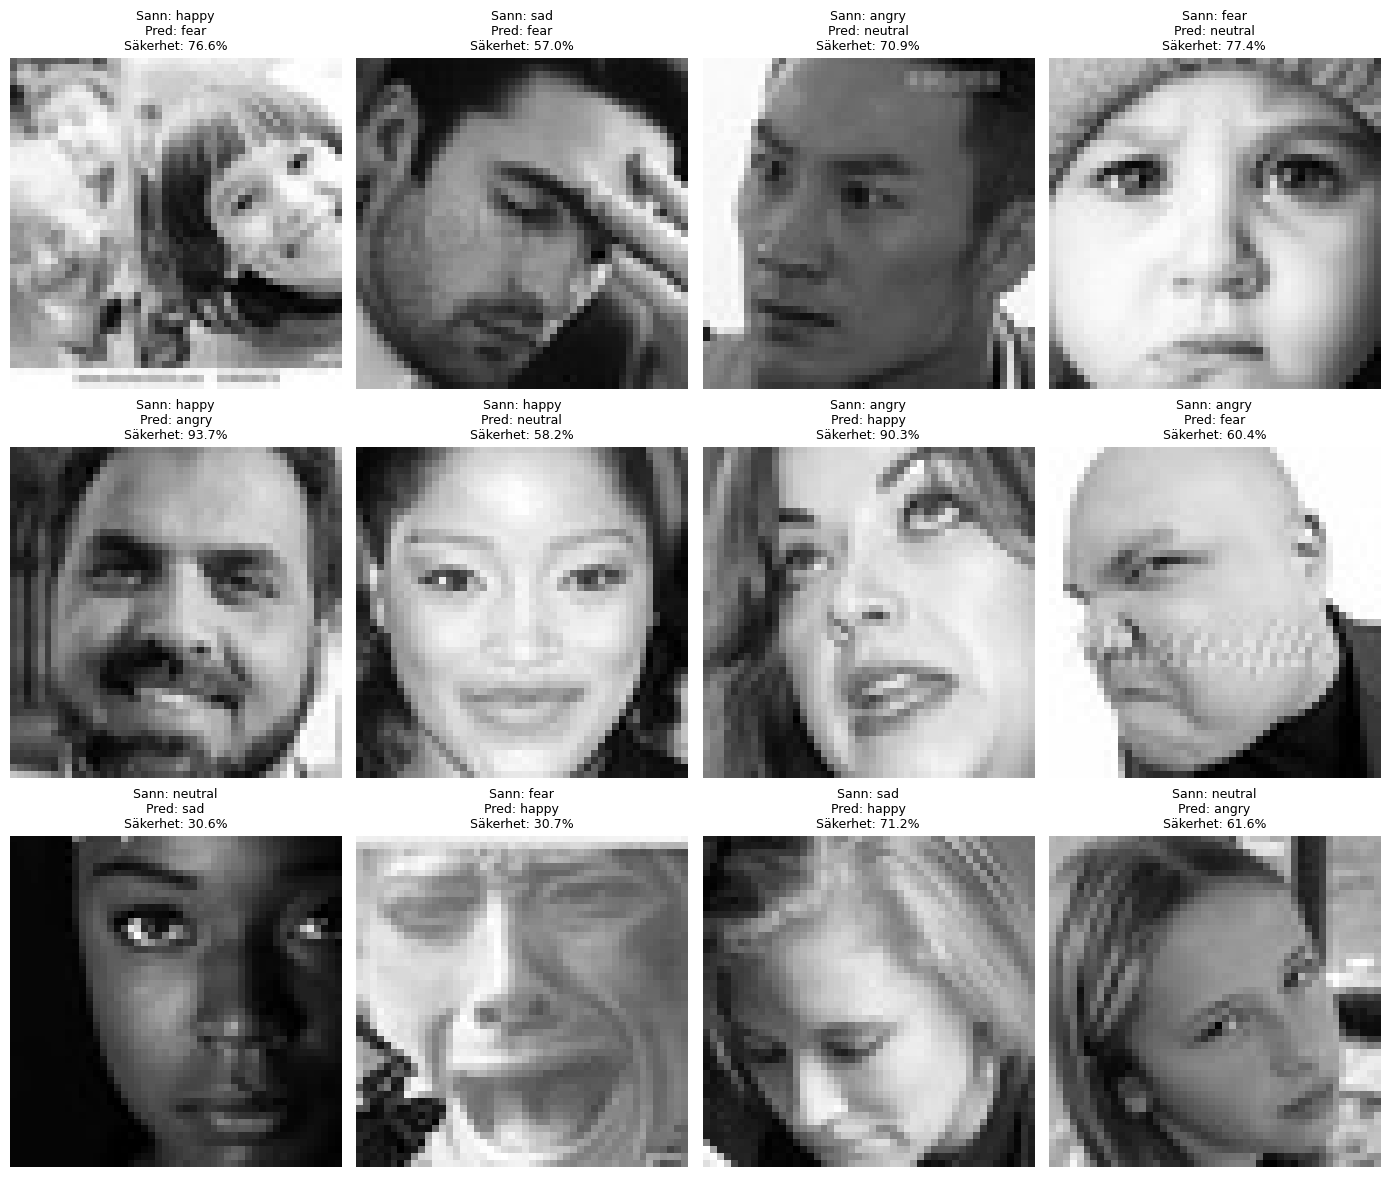

In [ ]:
def plot_misclassified_examples(
    X,
    y_true,
    y_pred,
    y_proba,
    class_names,
    n_images=12,
    random_state=42
):
    
    """
    Visar slumpmässigt utvalda felklassificerade bilder med sann klass,
    predikterad klass och modellens säkerhet.
    """

    error_indices = np.where(y_true != y_pred)[0]

    print(f"Antal felklassificerade exempel: {len(error_indices)}")

    if len(error_indices) == 0:
        print("Inga felklassificerade exempel att visa.")
        return

    rng = np.random.default_rng(random_state)

    chosen_indices = rng.choice(
        error_indices,
        size=min(n_images, len(error_indices)),
        replace=False
    )

    cols = 4
    rows = int(np.ceil(len(chosen_indices) / cols))

    plt.figure(figsize=(14, 4 * rows))

    for plot_index, data_index in enumerate(chosen_indices):
        true_label = y_true[data_index]
        pred_label = y_pred[data_index]
        confidence = y_proba[data_index, pred_label] * 100

        plt.subplot(rows, cols, plot_index + 1)
        plt.imshow(X[data_index].squeeze(), cmap="gray")
        plt.title(
            f"Sann: {class_names[true_label]}\n"
            f"Pred: {class_names[pred_label]}\n"
            f"Säkerhet: {confidence:.1f}%",
            fontsize=9
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Visar 12 slumpmässiga felklassificeringar med sann klass och modellens säkerhet
plot_misclassified_examples(
    X_val,
    y_val,
    final_model_val_pred,
    final_model_val_proba,
    class_names_filtered,
    n_images=12,
    random_state=42
)

## 5. Utvärdera modellen

Den slutliga modellen utvärderas på testdatan som inte använts under träning eller experimentfasen. Testdatan ger ett objektivt mått på hur väl modellen generaliserar till ny data. Resultaten jämförs med valideringsdatan för att kontrollera att modellen inte är överanpassad till valideringsdatan.

In [ ]:
# Laddar sparad modell och utvärderar på testdata
final_model = keras.models.load_model("final_model.keras")

test_loss, test_accuracy = final_model.evaluate(X_test_filtered, y_test_filtered, verbose=0)

# Jämför resultat på validerings- och testdata
comparison_overall = pd.DataFrame([
    {"dataset": "Validering", "accuracy": r_dropout_3layers_full["val_accuracy"], "loss": r_dropout_3layers_full["val_loss"]},
    {"dataset": "Test", "accuracy": test_accuracy, "loss": test_loss}
])

comparison_overall.style\
    .format({"accuracy": "{:.1%}", "loss": "{:.4f}"})\
    .background_gradient(subset=["accuracy"], cmap="RdYlGn")

,dataset,accuracy,loss
0,Validering,53.3%,1.7078
1,Test,52.3%,1.7691


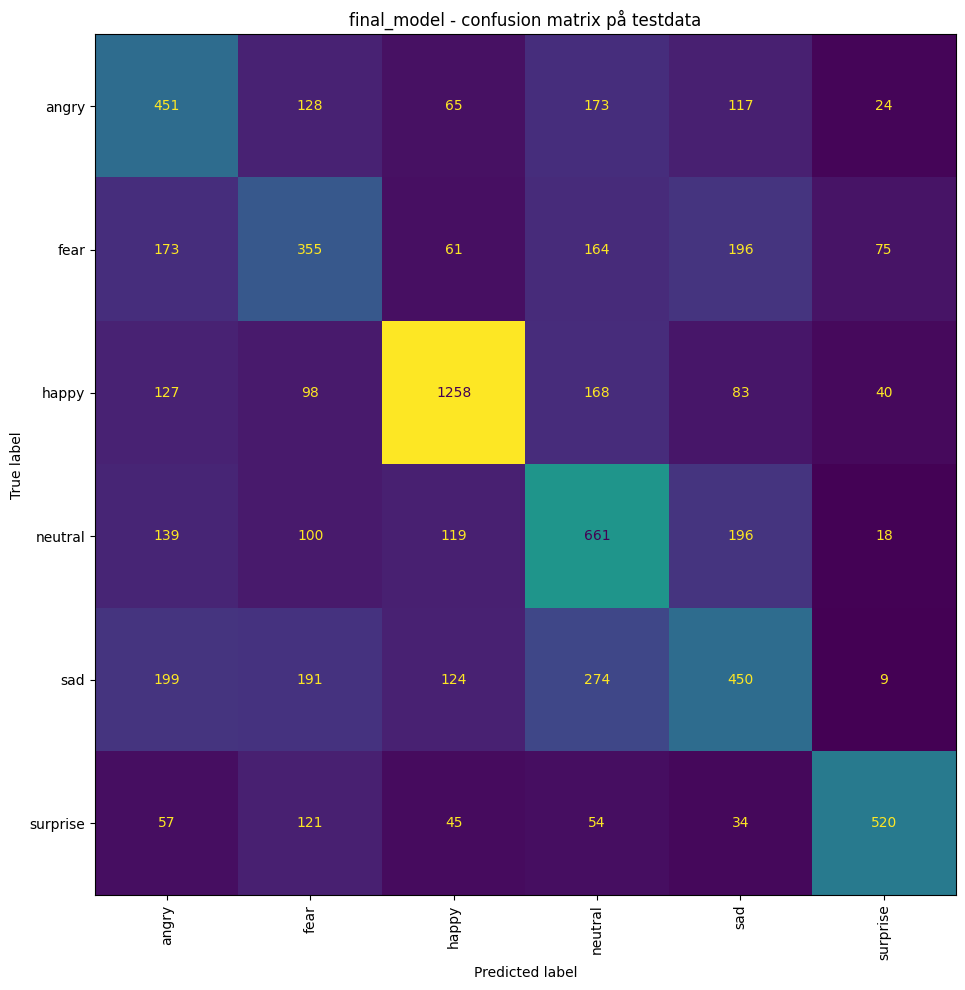

Per-klass accuracy på testdata


,class_id,class_name,support,correct,accuracy
1,1,fear,1024,355,34.7%
4,4,sad,1247,450,36.1%
0,0,angry,958,451,47.1%
3,3,neutral,1233,661,53.6%
5,5,surprise,831,520,62.6%
2,2,happy,1774,1258,70.9%


In [ ]:
# Predikterar på testdata
test_pred, test_proba = predict_classes(final_model, X_test_filtered)

# Konfusionsmatris på testdata
final_model_test_cm = plot_confusion_matrix(
    y_test_filtered,
    test_pred,
    class_names_filtered,
    title="final_model - confusion matrix på testdata"
)

# Per-klass accuracy på testdata
final_model_test_per_class = calculate_per_class_accuracy(
    final_model_test_cm,
    class_names_filtered
)

print("Per-klass accuracy på testdata")
final_model_test_per_class.style\
    .format({"accuracy": "{:.1%}"})\
    .background_gradient(subset=["accuracy"], cmap="RdYlGn")

In [ ]:
# Jämför per-klass accuracy mellan validerings- och testdata
comparison = final_model_per_class[["class_name", "accuracy"]].merge(
    final_model_test_per_class[["class_name", "accuracy"]],
    on="class_name",
    suffixes=("_val", "_test")
)

comparison.style\
    .format({"accuracy_val": "{:.1%}", "accuracy_test": "{:.1%}"})\
    .background_gradient(subset=["accuracy_val", "accuracy_test"], cmap="RdYlGn")

,class_name,accuracy_val,accuracy_test
0,sad,37.0%,36.1%
1,fear,37.1%,34.7%
2,angry,48.8%,47.1%
3,neutral,52.9%,53.6%
4,surprise,62.8%,62.6%
5,happy,72.1%,70.9%


Antal felklassificerade exempel: 3372


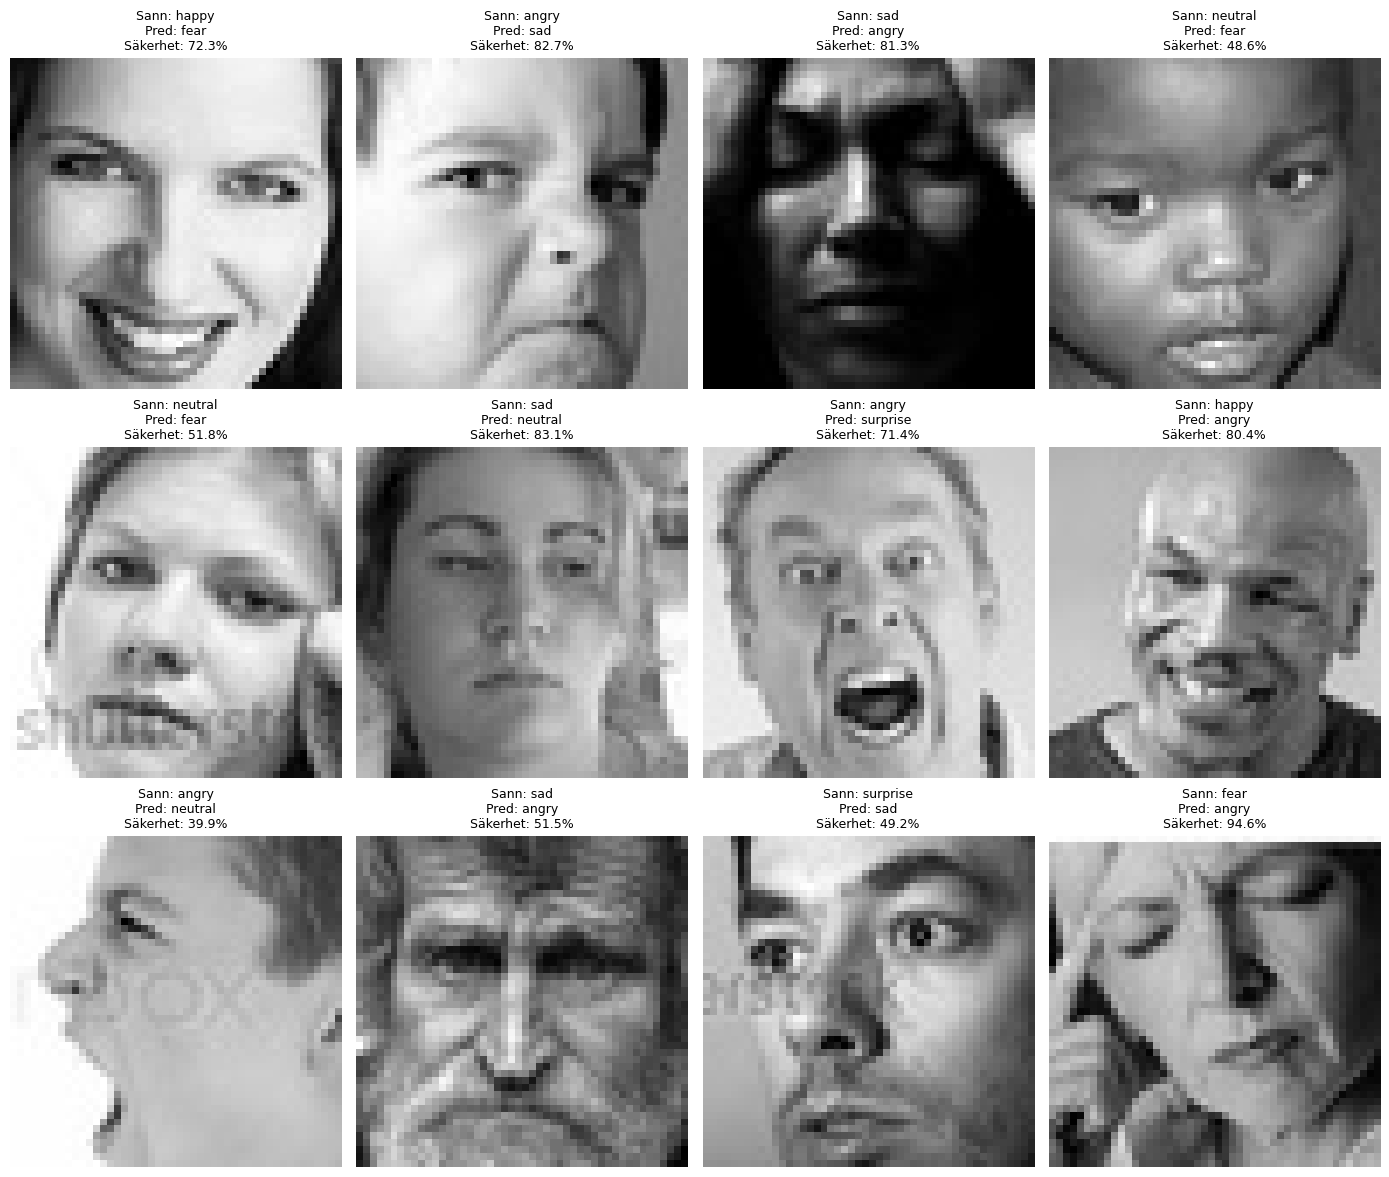

In [ ]:
# Visar 12 slumpmässiga felklassificeringar från testdata med sann klass och modellens säkerhet
plot_misclassified_examples(
    X_test_filtered,
    y_test_filtered,
    test_pred,
    test_proba,
    class_names_filtered,
    n_images=12,
    random_state=42
)

## 6. Gör prediktioner på ny data

För att visa att modellen fungerar som ett program används den för att klassificera en enskild bild från testdatan. Bilden förbereds på samma sätt som träningsdatan och modellen returnerar en sannolikhet för varje känslouttryck. Den klass med högst sannolikhet är modellens prediktion.

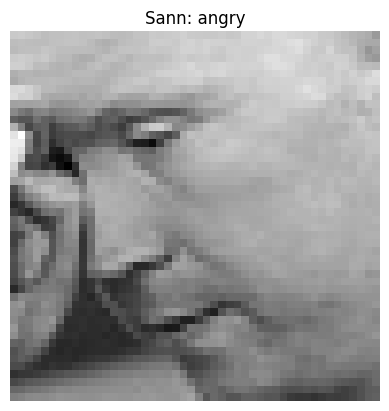

Sann label: angry
Predikterad label: sad


,Klass,Sannolikhet %
4,sad,54.5
1,fear,22.5
2,happy,10.4
3,neutral,7.8
0,angry,4.4
5,surprise,0.5


In [51]:
# Prediktion på en enskild bild från testdatan (index 18)
# Visar bilden, sann klass, predikterad klass och sannolikhet per klass
image_index = 18

probabilities = pd.DataFrame({
    "Klass": class_names_filtered,
    "Sannolikhet": test_proba[image_index]
})

probabilities = probabilities.sort_values(
    by="Sannolikhet",
    ascending=False
)

probabilities["Sannolikhet %"] = (probabilities["Sannolikhet"] * 100).round(2)

plt.imshow(X_test_filtered[image_index].squeeze(), cmap="gray")
plt.axis("off")
plt.title(f"Sann: {class_names_filtered[y_test_filtered[image_index]]}")
plt.show()

print("Sann label:", class_names_filtered[y_test_filtered[image_index]])
print("Predikterad label:", class_names_filtered[test_pred[image_index]])
probabilities[["Klass", "Sannolikhet %"]].style\
    .format({"Sannolikhet %": "{:.1f}"})\
    .background_gradient(subset=["Sannolikhet %"], cmap="RdYlGn")

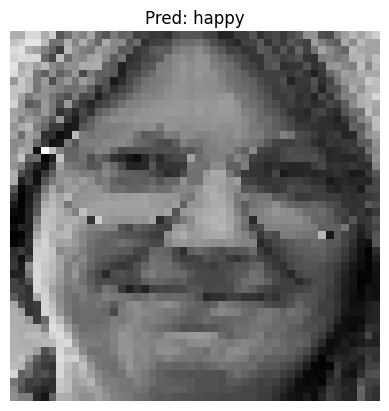

Predikterad label: happy


,Klass,Sannolikhet %
2,happy,92.8
3,neutral,3.0
1,fear,2.8
0,angry,1.0
4,sad,0.4
5,surprise,0.0


In [50]:
# Prediktion på en egen bild
# Visar bilden, predikterad klass och sannolikhet per klass
from tensorflow.keras.utils import load_img, img_to_array

img = load_img("data/egen_testbild.jpg", color_mode="grayscale", target_size=(48, 48))
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

pred_label, pred_proba = predict_classes(final_model, img_array)

probabilities = pd.DataFrame({
    "Klass": class_names_filtered,
    "Sannolikhet": pred_proba[0]
})

probabilities = probabilities.sort_values(
    by="Sannolikhet",
    ascending=False
)

probabilities["Sannolikhet %"] = (probabilities["Sannolikhet"] * 100).round(2)

plt.imshow(img_array.squeeze(), cmap="gray")
plt.axis("off")
plt.title(f"Pred: {class_names_filtered[pred_label[0]]}")
plt.show()

print("Predikterad label:", class_names_filtered[pred_label[0]])
probabilities[["Klass", "Sannolikhet %"]].style\
    .format({"Sannolikhet %": "{:.1f}"})\
    .background_gradient(subset=["Sannolikhet %"], cmap="RdYlGn")